<h1 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 12px 16px;
  border-radius: 10px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #22c55e;
">
Problemas de Estadística Descriptiva
</h1>

In [57]:
%pip install seaborn
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from scipy.stats import skew, kurtosis, mode

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 23.1.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


<h3 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 12px 16px;
  border-radius: 10px;
  text-align: justified;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #22c55e;
">
<span style="color:red;">Ejercicio 1</span> – ¿Qué tan largos son los títulos de las películas?

En este ejercicio vas a aplicar técnicas de estadística descriptiva sobre un conjunto de datos real: una base con 1000 películas populares del sitio IMDb.

A partir del título de cada película, vas a:
- Calcular la longitud del título (en caracteres).
- Obtener métricas estadísticas clave: media, mediana, moda, rango, varianza, desviación estándar, asimetría y curtosis.
- Identificar los títulos más largos y más cortos.
- Visualizar la distribución de estas longitudes con un histograma y una curva de densidad.
</h3>

In [58]:
# Cargar dataset de IMDb
url = "../assets/imdb_1000.csv"
df = pd.read_csv(url)
df

,star_rating,title,content_rating,genre,duration,actors_list
0,9.3,The Shawshank Redemption,R,Crime,142,"[u'Tim Robbins', u'Morgan Freeman', u'Bob Gunt..."
1,9.2,The Godfather,R,Crime,175,"[u'Marlon Brando', u'Al Pacino', u'James Caan']"
2,9.1,The Godfather: Part II,R,Crime,200,"[u'Al Pacino', u'Robert De Niro', u'Robert Duv..."
3,9.0,The Dark Knight,PG-13,Action,152,"[u'Christian Bale', u'Heath Ledger', u'Aaron E..."
4,8.9,Pulp Fiction,R,Crime,154,"[u'John Travolta', u'Uma Thurman', u'Samuel L...."
...,...,...,...,...,...,...
974,7.4,Tootsie,PG,Comedy,116,"[u'Dustin Hoffman', u'Jessica Lange', u'Teri G..."
975,7.4,Back to the Future Part III,PG,Adventure,118,"[u'Michael J. Fox', u'Christopher Lloyd', u'Ma..."
976,7.4,Master and Commander: The Far Side of the World,PG-13,Action,138,"[u'Russell Crowe', u'Paul Bettany', u'Billy Bo..."
977,7.4,Poltergeist,PG,Horror,114,"[u'JoBeth Williams', u""Heather O'Rourke"", u'Cr..."


<h3 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 12px 16px;
  border-radius: 10px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #22c55e;
">
Crea una nueva columna llamada 'title_length' con la longitud (número de caracteres) de cada título
</h3>

In [59]:
df["title"] = df["title"].fillna("").astype(str)                         # veo que title sea string y no tenga NaN
df["title_length"] = df["title"].str.len()                               # saco la nueva columna con la longitud del titulo
df[["title", "title_length"]].head(10)                                   # Imprimo 10 primeras peliculas

,title,title_length
0,The Shawshank Redemption,24
1,The Godfather,13
2,The Godfather: Part II,22
3,The Dark Knight,15
4,Pulp Fiction,12
5,12 Angry Men,12
6,"The Good, the Bad and the Ugly",30
7,The Lord of the Rings: The Return of the King,45
8,Schindler's List,16
9,Fight Club,10


<h3 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 12px 16px;
  border-radius: 10px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #22c55e;
">
Calcula media, mediana y moda de la columna 'title_length'
</h3>

In [60]:
media = df["title_length"].mean()                                        
mediana = df["title_length"].median()                                    
moda = df["title_length"].mode()[0]                                      

print(f"La media es: {media:.2f}")                                     
print(f"La mediana es: {mediana:.2f}")                                   
print(f"La moda es: {moda:.2f}")                                                   

La media es: 15.48
La mediana es: 14.00
La moda es: 12.00


<h3 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 12px 16px;
  border-radius: 10px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #22c55e;
">
Calcula el rango, la varianza y la desviación estándar de 'title_length'
</h3>

In [61]:
rango = df["title_length"].max() - df["title_length"].min()            
varianza = df["title_length"].var()                                      
desviacion = df["title_length"].std()                                 

print(f"El rango es: {rango:.2f}")                                       
print(f"La varianza es: {varianza:.2f}")                            
print(f"La desviacion estandar es: {desviacion:.2f}")                   

El rango es: 67.00
La varianza es: 72.11
La desviacion estandar es: 8.49


<h3 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 12px 16px;
  border-radius: 10px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #22c55e;
">
Calcula asimetría y curtosis de la columna 'title_length'
</h3>

In [62]:
asimetria = skew(df["title_length"])                                   
curtosis_val = kurtosis(df["title_length"])                            

print(f"La asimetria es: {asimetria:.4f}")                              
print(f"La curtosis es: {curtosis_val:.4f}")                             

La asimetria es: 1.5229
La curtosis es: 3.7867


<h3 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 12px 16px;
  border-radius: 10px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #22c55e;
">
Imprime el título más corto y el título más largo según su longitud
</h3>

In [63]:
idx_corto = df["title_length"].idxmin()                                  # indice del titulo mas corto y mas largo
idx_largo = df["title_length"].idxmax()                                 

titulo_corto = df.loc[idx_corto, "title"]                                # titulo mas corto y su longitud
len_corto = df.loc[idx_corto, "title_length"]                            

titulo_largo = df.loc[idx_largo, "title"]                                # titulo mas largo y su longitud
len_largo = df.loc[idx_largo, "title_length"]                            

print(f"El titulo mas corto es: '{titulo_corto}' ({len_corto} caracteres)")  
print(f"El titulo mas largo es: '{titulo_largo}' ({len_largo} caracteres)")   

El titulo mas corto es: 'M' (1 caracteres)
El titulo mas largo es: 'Dr. Strangelove or: How I Learned to Stop Worrying and Love the Bomb' (68 caracteres)


<h3 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 12px 16px;
  border-radius: 10px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #22c55e;
">
📈 Histograma 
</h3>

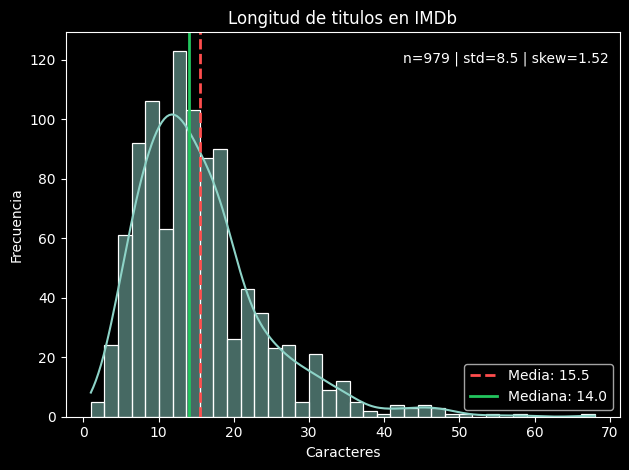

In [64]:
plt.style.use("dark_background")                                          

x = df["title_length"]                                                    
media = x.mean()                                                          
mediana = x.median()                                                      

ax = sns.histplot(x, kde=True, bins="fd")                                 

plt.axvline(media, color="#ff4d4d", linestyle="--", linewidth=2,        # media
            label=f"Media: {media:.1f}")
plt.axvline(mediana, color="#22c55e", linestyle="-", linewidth=2,       # mediana
            label=f"Mediana: {mediana:.1f}")

plt.title("Longitud de titulos en IMDb")                                 
plt.xlabel("Caracteres")                                                  # eje x
plt.ylabel("Frecuencia")                                                  # eje y
plt.legend()

ax.text(0.98, 0.95, f"n={len(x)} | std={x.std():.1f} | skew={skew(x):.2f}",
        transform=ax.transAxes, ha="right", va="top")                   

plt.tight_layout()
plt.show()

<h3 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 12px 16px;
  border-radius: 10px;
  text-align: justified;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #22c55e;
">
📊 Como conclusion podria decir que:

<br>La mayoria de las peliculas tienen titulos de una longitud parecida. No son ni extremadamente cortos ni exageradamente largos. 

Se observa que existen algunos titulos mas largos que el resto, pero son pocos. Estos casos hacen que el promedio suba un poco, aunque en general el comportamiento es bastante uniforme.

En resumen, los titulos de las peliculas populares tienden a mantener una estructura relativamente similar en tamaño, con algunas excepciones que se salen de lo habitual.
</h3>

<h3 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 12px 16px;
  border-radius: 10px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #22c55e;
">
📈 Boxplot
</h3>

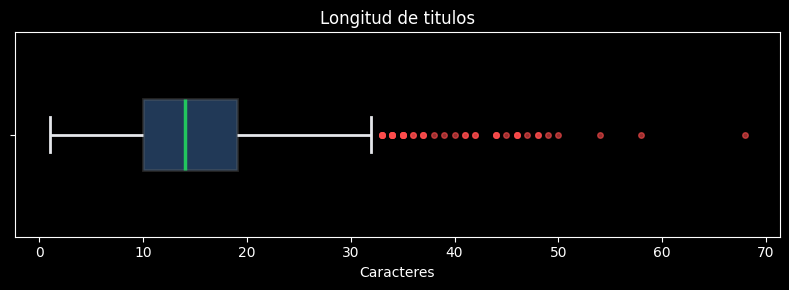

In [65]:
plt.style.use("dark_background")                                          

plt.figure(figsize=(8, 3))                                               

sns.boxplot(
    x=df["title_length"],
    width=0.35,
    linewidth=2,
    boxprops={"facecolor": "#60a5fa", "alpha": 0.35},                     
    medianprops={"color": "#22c55e", "linewidth": 2.5},                   
    whiskerprops={"color": "#e5e7eb", "linewidth": 2},                    
    capprops={"color": "#e5e7eb", "linewidth": 2},                        
    flierprops={"marker": "o", "markersize": 4, "alpha": 0.6,           
                "markerfacecolor": "#ff4d4d", "markeredgecolor": "#ff4d4d"})

plt.title("Longitud de titulos")         
plt.xlabel("Caracteres")                                                  

plt.tight_layout()
plt.show()

<h3 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 12px 16px;
  border-radius: 10px;
  text-align: justified;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #22c55e;
">
📊 Como conclusion podria decir que:

<br>El boxplot confirma que la mayoria de los titulos se concentran en un rango relativamente compacto de caracteres. La mediana se encuentra dentro de la caja, lo que indica que el tamaño tipico de los titulos es bastante estable.

Se pueden observar algunos puntos fuera de los bigotes, lo que representa titulos mas largos de lo normal. Estos casos no son la mayoria, pero si muestran que existen excepciones que se alejan del comportamiento general.

En resumen, aunque hay algunos titulos mas extensos, la estructura general de los titulos es bastante consistente y no presenta una dispersion extrema.
</h3>

<h3 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 12px 16px;
  border-radius: 10px;
  text-align: jutified;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #22c55e;
">
<span style="color:red;">Ejercicio 2</span> – Cálculo manual de desviación estándar

En este ejercicio vas a calcular manualmente la desviación estándar, seleccionando cinco títulos reales del dataset de películas que cargaste antes.
</h3>

<h3 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 12px 16px;
  border-radius: 10px;
  text-align: jutified;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #22c55e;
">
No elegi las peliculas al azar. Decidi tomar las cinco mejor valoradas del genero de accion. 
</h3>

In [ ]:
# Crea una lista con 5 valores reales de df['title_length'], por ejemplo: [10, 13, 14, 18, 22]

df_action = df[df["genre"].str.contains("Action", na=False)]              # filtro solo genero Action 
top_5 = df_action.sort_values("star_rating", ascending=False).head(5)     # ordeno por rating y tomo las primeras cinco

lista_top_5 = top_5["title_length"].tolist()                              # longitudes en lista

top_5[["title", "genre", "star_rating", "title_length"]]                  # miro que peliculas salieron
print("\nLista final de longitudes:")
print(lista_top_5)

tabla_top_5 = top_5[["title", "genre", "star_rating", "title_length"]].copy()  
tabla_top_5 = tabla_top_5.reset_index(drop=True)                                
tabla_top_5                                                                    


Lista final de longitudes:
[15, 9, 46, 9, 10]


,title,genre,star_rating,title_length
0,The Dark Knight,Action,9.0,15
1,Inception,Action,8.8,9
2,Star Wars: Episode V - The Empire Strikes Back,Action,8.8,46
3,Star Wars,Action,8.7,9
4,The Matrix,Action,8.7,10


In [77]:
# Calcula la media de los 5 valores

media_5 = sum(lista_top_5) / len(lista_top_5)                             
print(f"La media de los 5 valores es: {media_5:.2f}")                   

La media de los 5 valores es: 17.80


In [78]:
# Calcula las diferencias al cuadrado con respecto a la media

diferencias_cuadrado = [(x - media_5) ** 2 for x in lista_top_5]          
print("Diferencias al cuadrado respecto a la media:")                      
print(diferencias_cuadrado)                                               

Diferencias al cuadrado respecto a la media:
[7.840000000000004, 77.44000000000001, 795.24, 77.44000000000001, 60.84000000000001]


In [79]:
# Calcula la varianza (promedio de las diferencias al cuadrado) y su raíz cuadrada para obtener la desviación

varianza_5 = sum(diferencias_cuadrado) / len(diferencias_cuadrado)       
desviacion_5 = varianza_5 ** 0.5                                           

print(f"La varianza de los 5 valores es: {varianza_5:.2f}")                
print(f"La desviacion estandar de los 5 valores es: {desviacion_5:.2f}")  

La varianza de los 5 valores es: 203.76
La desviacion estandar de los 5 valores es: 14.27
